In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
import os

os.makedirs("../images", exist_ok=True)
print("images/ folder ready")

images/ folder ready


In [58]:
train = pd.read_csv("../data/raw/train.csv", dtype={"StateHoliday": str})
store = pd.read_csv("../data/raw/store.csv")

In [59]:
train_open = train[train['Open'] == 1 ]

print(f"Full dataset:       {len(train):,} rows")
print(f"Open stores only:   {len(train_open):,} rows")
print(f"Closed days removed: {len(train) - len(train_open):,} rows")

Full dataset:       1,017,209 rows
Open stores only:   844,392 rows
Closed days removed: 172,817 rows


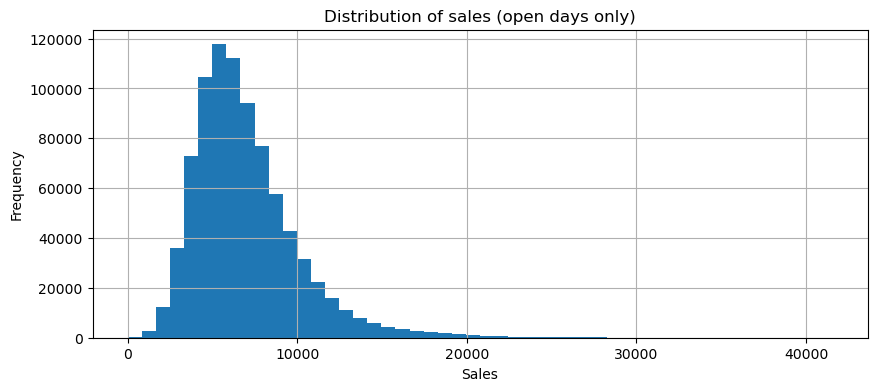

count    844392.00
mean       6955.51
std        3104.21
min           0.00
25%        4859.00
50%        6369.00
75%        8360.00
max       41551.00
Name: Sales, dtype: float64


In [60]:
train_open["Sales"].hist(bins=50, figsize=(10, 4))

plt.title("Distribution of sales (open days only)")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.savefig("../images/01_sales_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(train_open["Sales"].describe().round(2))

In [61]:
train_open = train_open.copy()
train_open['Date'] = pd.to_datetime(train_open['Date'])

train_open['Year'] = train_open['Date'].dt.year
train_open['Month'] = train_open['Date'].dt.month
train_open['Week'] = train_open['Date'].dt.isocalendar().week.astype(int)

train_open.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Week
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31


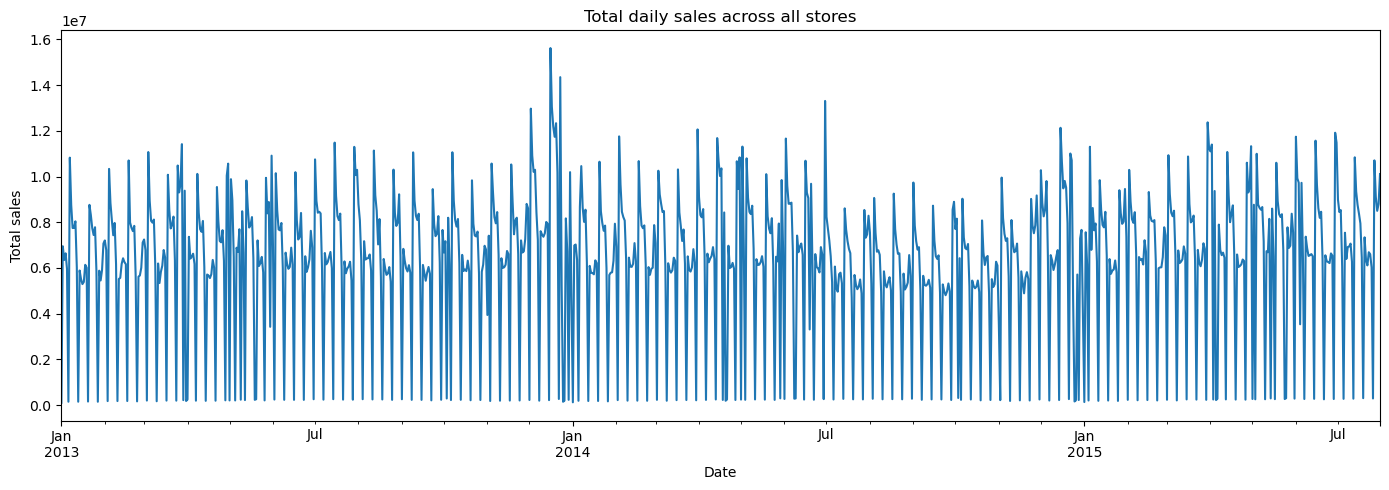

In [62]:
daily_sales = train_open.groupby('Date')['Sales'].sum()

daily_sales.plot(figsize=(14, 5))
plt.title("Total daily sales across all stores")
plt.xlabel("Date")
plt.ylabel("Total sales")
plt.tight_layout()
plt.savefig("../images/02_daily_sales_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()


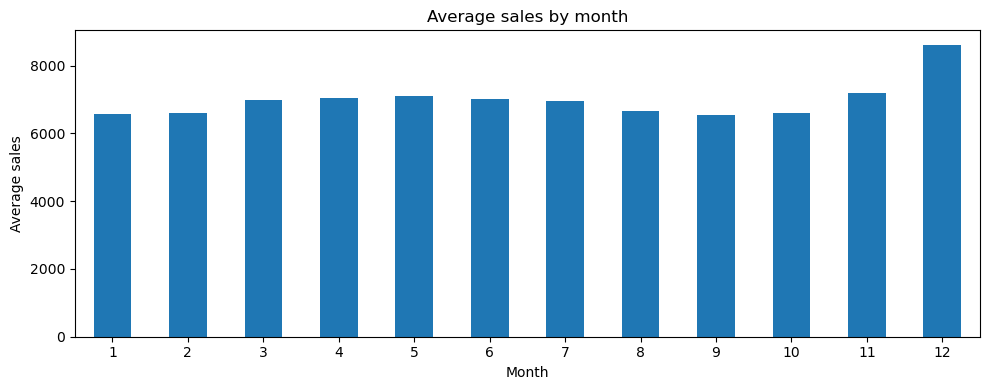

Month
1     6563.69
2     6589.17
3     6976.41
4     7046.23
5     7106.45
6     7000.98
7     6952.68
8     6648.98
9     6546.34
10    6602.84
11    7188.55
12    8608.96
Name: Sales, dtype: float64


In [63]:
monthly_sales = train_open.groupby("Month")["Sales"].mean()

monthly_sales.plot(kind="bar", figsize=(10, 4))
plt.title("Average sales by month")
plt.xlabel("Month")
plt.ylabel("Average sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/03_monthly_sales.png", dpi=150, bbox_inches="tight")
plt.show()

print(monthly_sales.round(2))

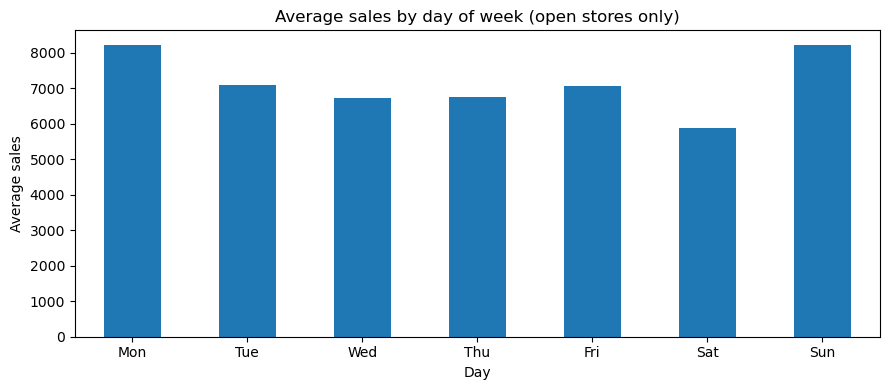

DayOfWeek
Mon    8216.07
Tue    7088.11
Wed    6728.12
Thu    6767.31
Fri    7072.68
Sat    5874.84
Sun    8224.72
Name: Sales, dtype: float64


In [64]:
day_names = {1:"Mon", 2:"Tue", 3:"Wed", 4:"Thu", 5:"Fri", 6:"Sat", 7:"Sun"}

sales_by_day = train_open.groupby("DayOfWeek")["Sales"].mean()
sales_by_day.index = sales_by_day.index.map(day_names)

sales_by_day.plot(kind="bar", figsize=(9, 4))
plt.title("Average sales by day of week (open stores only)")
plt.xlabel("Day")
plt.ylabel("Average sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/04_sales_by_day_of_week.png", dpi=150, bbox_inches="tight")
plt.show()

print(sales_by_day.round(2))

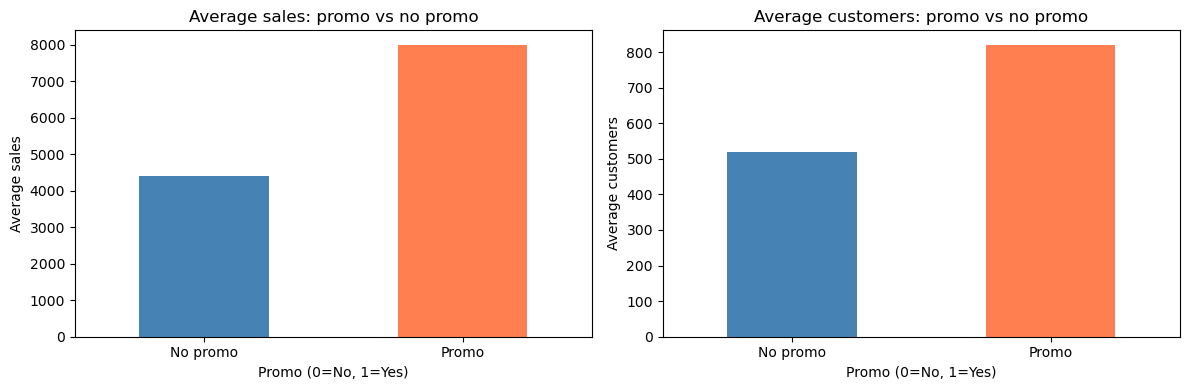

Average promo sales Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64
Average promo customers Promo
0    517.823542
1    820.098815
Name: Customers, dtype: float64


In [65]:
promo_sales = train.groupby('Promo')['Sales'].mean()
promo_customers = train.groupby('Promo')['Customers'].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

promo_sales.plot(
    kind='bar', ax=ax[0], color=["steelblue", "coral"]
)

ax[0].set_title("Average sales: promo vs no promo")
ax[0].set_xlabel("Promo (0=No, 1=Yes)")
ax[0].set_ylabel("Average sales")
ax[0].set_xticklabels(["No promo", "Promo"], rotation=0)

promo_customers.plot(
    kind='bar', ax=ax[1], color=["steelblue", "coral"]
)
ax[1].set_title("Average customers: promo vs no promo")
ax[1].set_xlabel("Promo (0=No, 1=Yes)")
ax[1].set_ylabel("Average customers")
ax[1].set_xticklabels(["No promo", "Promo"], rotation=0)

plt.tight_layout()
plt.savefig("../images/05_promo_impact.png", dpi=150, bbox_inches="tight")
plt.show()

print(f'Average promo sales {promo_sales}')
print(f'Average promo customers {promo_customers}')

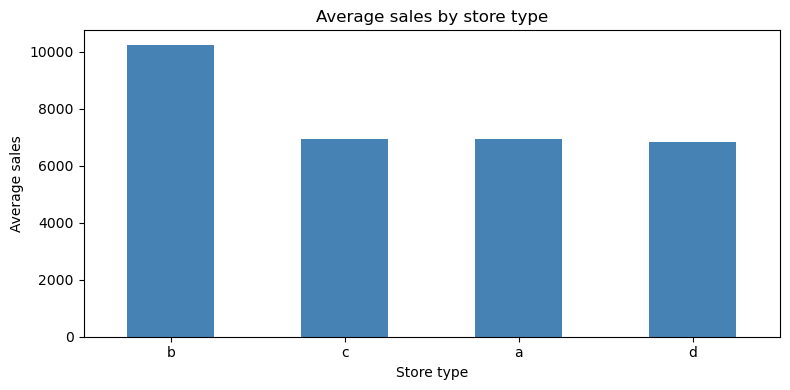

StoreType
b    10231.41
c     6932.51
a     6925.17
d     6822.14
Name: Sales, dtype: float64


In [66]:
merged = train_open.merge(store, on='Store', how='left')

store_type_sales = merged.groupby('StoreType')['Sales'].mean().sort_values(ascending=False)

store_type_sales.plot(kind='bar', figsize=(8, 4), color='steelblue')
plt.title("Average sales by store type")
plt.xlabel("Store type")
plt.ylabel("Average sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/06_store_type_sales.png", dpi=150, bbox_inches="tight")
plt.show()

print(store_type_sales.round(2))


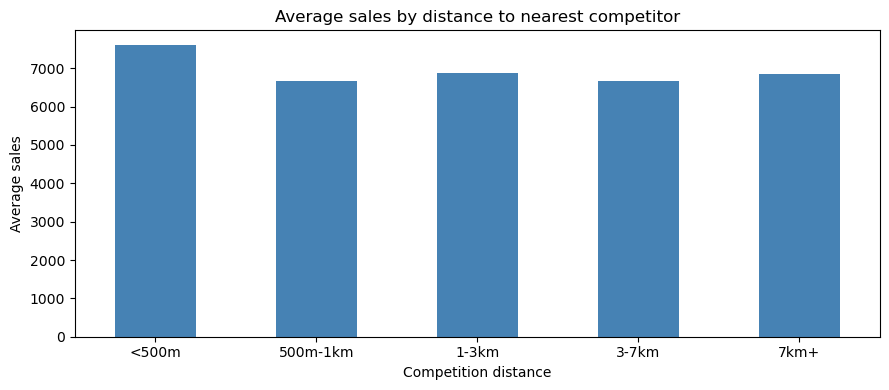

In [67]:
merged['CompetitionDistance'].fillna(merged['CompetitionDistance'].median())

merged['DistanceBucket'] = pd.cut(
    merged['CompetitionDistance'],
    bins=[0, 500, 1000, 3000, 7000, 100000],
    labels=["<500m", "500m-1km", "1-3km", "3-7km", "7km+"]
)

merged.groupby('DistanceBucket', observed=False)['Sales'].mean().plot(
    kind='bar', figsize=(9, 4), color='steelblue'
)

plt.title("Average sales by distance to nearest competitor")
plt.xlabel("Competition distance")
plt.ylabel("Average sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/07_competition_distance.png", dpi=150, bbox_inches="tight")
plt.show()


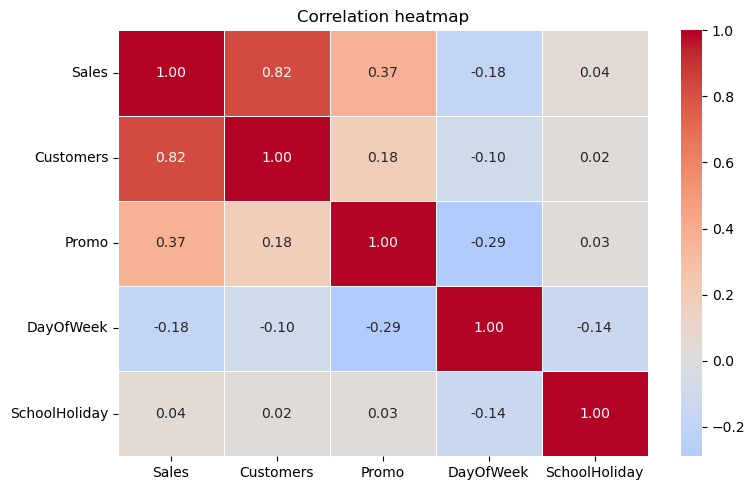

In [68]:
cols = ["Sales", "Customers", "Promo", "DayOfWeek", "SchoolHoliday"]

corr = train_open[cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig("../images/08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

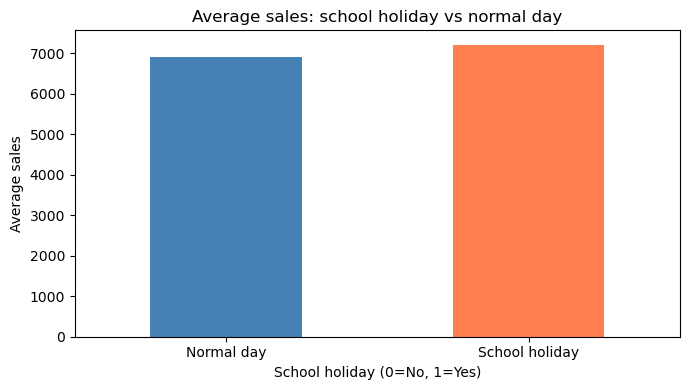

SchoolHoliday
0    6896.78
1    7200.18
Name: Sales, dtype: float64


In [69]:
holiday_sales = train_open.groupby("SchoolHoliday")["Sales"].mean()

holiday_sales.plot(kind="bar", figsize=(7, 4), color=["steelblue", "coral"])
plt.title("Average sales: school holiday vs normal day")
plt.xlabel("School holiday (0=No, 1=Yes)")
plt.ylabel("Average sales")
plt.xticks([0, 1], ["Normal day", "School holiday"], rotation=0)
plt.tight_layout()
plt.savefig("../images/09_school_holiday_sales.png", dpi=150, bbox_inches="tight")
plt.show()

print(holiday_sales.round(2))

In [70]:
state_holiday_sales = train_open.groupby("StateHoliday")["Sales"].mean().sort_values(ascending=False)

print(state_holiday_sales.round(2))

StateHoliday
b    9887.89
c    9743.75
a    8487.47
0    6953.52
Name: Sales, dtype: float64


## Key Findings from EDA

These are the patterns the data revealed before any modelling.

### Dataset
- 1,017,209 total rows across 1,115 stores (2013–2015)
- 172,817 closed-store days removed — all analysis below is on open days only (844,392 rows)

### Sales distribution
- Average sales per open day: **6,955**
- Range: 0 to 41,551 — significant variance across stores

### Seasonality
- December is the strongest month (avg 8,609) — 24% above the yearly average
- September is the weakest month (avg 6,546)
- Monday and Sunday are the strongest days of the week (~8,200 avg)
- Saturday is the weakest day (avg 5,875)

### Promotions
- Promo days drive 81% higher average sales (7,991 vs 4,406)
- Promo days attract 58% more customers (820 vs 518)
- Note: correlation coefficient understates this — groupby mean is the correct measure for binary features

### Store type
- Store type B significantly outperforms others (avg 10,231 vs ~6,900 for A, C, D)
- Store type B also attracts nearly 3x more customers than other types

### Holidays
- Easter (b) and Christmas (c) state holidays drive the highest sales (~9,700–9,900)
- School holidays show a modest positive effect (7,200 vs 6,897 on normal days)

### Competition
- Stores with very close competitors (<500m) do not necessarily underperform
- Suggests store location quality may matter more than competition proximity

### Implications for feature engineering
- Month, week, and day-of-week must be extracted from Date
- Promo will be one of the most important model features
- StoreType and Assortment from store.csv must be included
- StateHoliday and SchoolHoliday should be encoded properly
- CompetitionDistance missing values should be filled with median
